# <center><font color=navy>Data Science for Quantitative Finance</font></center>
## <center><font color=navy>Value at Risk (VaR): Mathematical Fundation</font> </center>
### <center> Ali Habibnia</center>

    
<center> Assistant Professor, Department of Economics, </center>
<center> and Division of Computational Modeling & Data Analytics at Virginia Tech</center>
<center> habibnia@vt.edu </center> 

---
## **1. Introduction to Value at Risk (VaR)**

Value at Risk (**VaR**) is a statistical measure used in risk management to estimate the **worst expected loss** of a financial asset or portfolio over a given time horizon at a specific confidence level

Mathematically, it is defined as:

$$ P(R_t \leq -VaR) = \alpha $$

where:
- $ R_t $ is the return of the asset or portfolio at time $ t $,
- $ \alpha $ is the significance level (e.g., 1% or 5%),
- $ VaR $ is the maximum expected loss at the given confidence level.

 **Key Intuition**

- If the **1-day 99% VaR = $1M**, this means that **there is a 1% probability of losing more than $1M in one day**.
- The **higher the confidence level**, the larger the VaR.
---

## **2. Methods for VaR Calculation**

### **2.1 Parametric (Variance-Covariance) Method**
Assuming that **returns follow a normal distribution**, VaR can be estimated as:

$$ VaR = Z_{\alpha} \cdot \sigma \cdot \sqrt{T} $$

where:
- $ Z_{\alpha} $ is the standard normal quantile for confidence level $ 1 - \alpha $,
- $ \sigma $ is the standard deviation of portfolio returns (volatility),
- $ T $ is the time horizon.

### **2.2 Historical Simulation Method**
This **non-parametric** method calculates VaR directly from historical return data without assuming a normal distribution.

Mathematically:

$$ VaR = Quantile_{\alpha}(R_t) $$

The process:

1. Collect historical daily returns.
2. Rank them from worst to best.
3. Select the quantile corresponding to $1−\alpha$

Example:

Assume we have 100 days of returns sorted from worst to best. The 5th worst return (since 99% VaR means 1% probability) represents the VaR threshold.


### **2.3 Monte Carlo Simulation**
Monte Carlo methods simulate thousands of possible future price movements based on assumed distributions. VaR is then estimated from the simulated distribution.

Returns are simulated using:

$$ R_t = \mu + \sigma Z_t $$

where:
- $ \mu $ is the expected return,
- $ \sigma $ is the volatility,
- $ Z_t \sim N(0,1) $ is a standard normal random variable.

Steps:

1. Assume a return distribution (e.g., normal or GARCH model).
2. Generate many random return paths.
3. Compute the worst $\alpha$% quantile.

### **2.4 GARCH-Based VaR**
GARCH models **estimate time-varying volatility** in financial markets. Unlike the parametric method, which assumes constant volatility, GARCH models estimate time-varying volatility, which improves risk estimation.

GARCH(1,1) model:

$$ \sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2 $$

VaR is computed using:

$$ VaR_t = Z_{\alpha} \cdot \sigma_t $$

---

## **3. Conditional Value at Risk (CVaR) - Expected Shortfall**

**What is CVaR?**
Conditional Value at Risk (**CVaR**), also known as **Expected Shortfall (ES)**, is an extension of Value at Risk (**VaR**) that accounts for **extreme losses beyond the VaR threshold**.

While VaR only tells us the loss threshold at a certain confidence level, CVaR measures the average loss in the worst-case scenarios, i.e., in the $ \alpha $% tail of the loss distribution.


For a given confidence level $ 1 - \alpha $, CVaR is defined as:

$$
CVaR_{\alpha} = E[R_t | R_t \leq -VaR_{\alpha}]
$$

where:
- $ R_t $ represents the portfolio return,
- $ VaR_{\alpha} $ is the **$ \alpha $%-quantile loss threshold**,
- $ CVaR_{\alpha} $ is the **expected loss given that losses exceed VaR**.

**Why is CVaR Important?**
- **Addresses VaR Limitations**: VaR only considers a threshold but does not describe how bad losses can be beyond that point.
- **More Conservative Risk Measure**: CVaR accounts for the **severity of tail risk**.
- **Better for Portfolio Optimization**: Used in **risk-aware investment strategies**.

**Interpretation**
- If 99% VaR is \$500,000, this means that on 1% of worst days, losses exceed \$500,000.
- If 99% CVaR is \$700,000, this means that when losses exceed VaR, the average loss is \$700,000.

Thus, CVaR provides a more comprehensive view of tail risk than VaR.

**CVaR in Risk Management**
- Used by financial institutions for **stress testing and extreme risk assessment**.
- More reliable than VaR for **hedging strategies** and **regulatory compliance (e.g., Basel Accords).**

---


In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm
from arch import arch_model

In [5]:
# Fetch historical data
symbol = "SPY"
data = yf.download(symbol, start="2020-01-01", end="2025-01-01")
returns = data["Close"].pct_change().dropna()

# Portfolio settings
portfolio_value = 10_000_000  # $10M portfolio
confidence_level = 0.99
Z_alpha = norm.ppf(confidence_level)  # Z-score for 99% confidence


[*********************100%***********************]  1 of 1 completed


In [11]:
# 1. Parametric (Variance-Covariance) VaR
sigma = returns.std(axis=0)  # Standard deviation of returns
VaR_parametric = Z_alpha * sigma * portfolio_value
VaR_parametric

Ticker
SPY    307707.346955
dtype: float64

In [13]:
# 2. Historical Simulation VaR
VaR_historical = np.percentile(returns, (1 - confidence_level) * 100) * portfolio_value
VaR_historical

np.float64(-361644.66528306395)

In [19]:
# 3. Monte Carlo Simulation VaR
simulations = 10000
mu = returns.mean().iloc[0]
sigma_mc = returns.std(axis=0).iloc[0]
simulated_returns = np.random.normal(mu, sigma_mc, simulations)
VaR_monte_carlo = np.percentile(simulated_returns, (1 - confidence_level) * 100) * portfolio_value
VaR_monte_carlo

np.float64(-297020.62708196393)

In [15]:
# 4. GARCH-Based VaR
garch_model = arch_model(returns * 100, vol="Garch", p=1, q=1, dist="t")
garch_fit = garch_model.fit(disp="off")
garch_forecast = garch_fit.forecast(start=returns.index[-1], horizon=1)
sigma_garch = np.sqrt(garch_forecast.variance.values[-1, :][0]) / 100
VaR_garch = Z_alpha * sigma_garch * portfolio_value
VaR_garch

np.float64(244306.6871402814)

In [20]:
# 5. Conditional VaR (Expected Shortfall)
CVaR_historical = returns[returns <= VaR_historical / portfolio_value].mean() * portfolio_value
CVaR_historical

Ticker
SPY   -563042.145521
dtype: float64

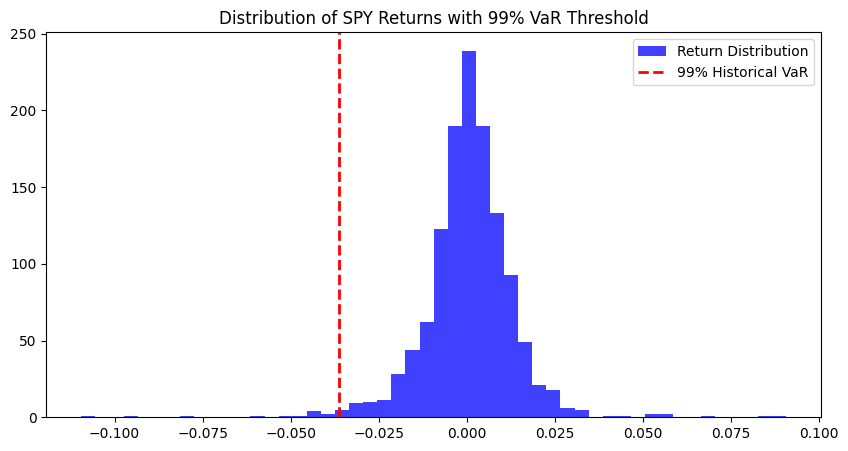

In [18]:
# Plot Historical Returns and VaR Thresholds
plt.figure(figsize=(10,5))
plt.hist(returns, bins=50, alpha=0.75, color='blue', label='Return Distribution')
plt.axvline(VaR_historical / portfolio_value, color='red', linestyle='dashed', linewidth=2, label='99% Historical VaR')
plt.title('Distribution of SPY Returns with 99% VaR Threshold')
plt.legend()
plt.show()
